In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://thewolfsound.com/bilinear-transform/


The bilinear transform is a method for designing digital filters from analog models. More precisely, it brings filters from the Laplace domain to the z-domain:

$$
H(s) \xrightarrow[\text{Transform}]{\text{Bilinear}} H(z)
$$

In contrast to the impulse invariance method (that operates in the time domain), the bilinear transform is performed in the frequency domain.
To do this, the continuous-time s-plane is morphed to the disrete-time z-plane by bending the frequency axis to become the unit circle:

In [2]:


fig, ax = plt.subplots()
ax.axis('equal')


ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

plt.fill_between([-1.2,0], [1.2,1.2],-1.2 ,  color='gray', alpha=0.2);


#plt.plot(-0.5,0,'xk',label='Pole');

plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc='lower right');



theta  = np.linspace( 0 , np.pi , 150 )
radius = 1
a = radius * np.cos( theta )
b = radius * np.sin( theta )

l, =  plt.plot( [0,0], [-10,10] , 'k--', linewidth=2)



x = np.arange(-2, 2, 0.01)
y1 = np.sin(2 * np.pi * x)-10

plt.legend(loc=(0.75,-0.05));
plt.xlim([-1.5,1.5]);
plt.ylim([-1.5,1.5]);


plt.close()


def animate(i):

    
    radius = 1+pow(2*i,4)
    
    xoff   = (radius)-(1-i)
    
    theta  = np.linspace( -np.pi , np.pi , 150 )
    
    a = radius * np.cos( theta )-xoff
    b = radius * radius* np.sin( theta )
    
    l.set_data(a,b)
    


    ax.fill_between(x, y1, 2,color='white')
    ax.fill_between(a, b, color='gray',alpha=0.3)

                 
    
rs  = np.linspace(1,0,100)

ani = matplotlib.animation.FuncAnimation(fig, animate, rs)


HTML(ani.to_jshtml())
HTML(ani.to_jshtml())



---

To get the bilinear transform for a given $H(s)$, we need to substitute $s$ with:

$$
\boxed{
s = \frac{2}{T} \frac{1-z^{-1}}{1+z^{-1}}
}
$$

with the sampling period $T$:

$$
T=\frac{1}{f_s}
$$

----

# Passive RC Lowpass Example

A simple example for the bilinear transform can be shown for the first order RC lowpass:

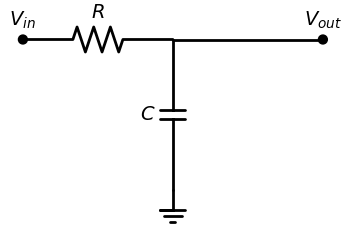

In [3]:
d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Resistor().label('$R$'))
d.push() 

d.add(e.Capacitor().down().label('$C$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()


----

## Transfer Function

The resulting filter has a low pass characteristic with the following frequency response:



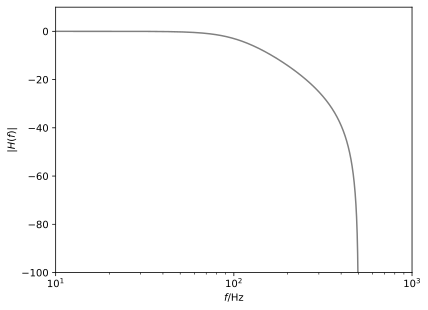

In [4]:

b, a = signal.butter(1, 100,fs=1000)

z,p, k = signal.butter(2, 100, output='zpk', fs=1000)

w, h = signal.freqz_zpk(z, p, k, fs=1000)

fig  = plt.figure()

ax   = fig.add_subplot(111)

ax.plot(w, 20 * np.log10(abs(h)),color = [0.5,0.5,0.5]);

ax.set_xscale('log')
ax.axis((10, 1000, -100, 10));

plt.xlabel('$f/\mathrm{Hz}$');
plt.ylabel('$|H(f)|$');
    



In the Laplace domain its transfer function is defined as (see [Laplace Section](https://ringbuffer.org/dsp/Digital_Filters/Laplace%20Transform/#Analysing-a-Circuit-in-the-Laplace-Domain)):

$$
H(s) = \frac{\omega_c}{\omega_c + s} =  \frac{1}{1 + \frac{s}{\omega_c}} 
$$

$s$ represents the Laplace operator:

$$
s = \sigma + j \omega 
$$

The cutoff frequency $\omega_c$ of the passive filter is:

$$
\omega_c = \frac{1}{RC}
$$

----

## Substitution

For a transform to the z-domain, the Laplace operator $s$ is subsstituted by the $z$ operator:

$$
s = \frac{2}{T}\frac{1-z^{-1}}{1+z^{-1}}
$$



The following steps rearrange the resulting transfer function to be comprised of two polynomials with $z^{-n}$:

$$
\begin{align} %
%
H(z) = & \frac{\omega_c}{\omega_c + \frac{2}{T}  \frac{1-z^{-1}}{1+z^{-1}}} \\ 
%
= & \frac{\frac{T}{2} \omega_c}{ \frac{T}{2} \omega_c +   \frac{1-z^{-1}}{1+z^{-1}}} \\
% 
= & \frac{\frac{T}{2} \omega_c (1+ z^{-1})}{ \frac{T}{2} \omega_c (1+ z^{-1}) +   1-z^{-1}} \\
%
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \frac{T}{2} \omega_c (1+ z^{-1}) +   1-z^{-1}} \\
%
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \frac{T}{2} \omega_c + \frac{T}{2} \omega_c z^{-1} +  1-z^{-1}} \\
%  
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{1 + \frac{T}{2} \omega_c + (\frac{T}{2} \omega_c -1 )z^{-1}} \\
%
\end{align}
$$


-----

For getting the coefficients of our digital filter, the transfer function needs to meet the following structure with $a_0=1$:


$$
H(z) = \frac{b_0 + b_1 z^{-1}}{1+ a_1 z^{-1}}
$$

This is achieved by expanding and simplifying:

$$
\begin{align} %
%
  H(z)  = & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \underbrace{ \mathbf{\color{gray} 1 + \frac{T}{2} \omega_c }}_{\text{must be 1}} + \left(\frac{T}{2} \omega_c -1 \right)z^{-1}} \\
 %
  = & \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c}{1 + \frac{T}{2} \omega_c} - \frac{1}{1 + \frac{T}{2} \omega_c} \right)z^{-1}} \\
 %
 = & \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}  \right)z^{-1}} \\
\end{align}
$$

-----

## Coefficients

Following the above rearrangements, the coefficients can be directly extracted from the transfer funcion:

$$
H(z) = \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}  \right)z^{-1}} = \frac{b_0 + b_1 z^{-1}}{1+ a_1 z^{-1}}
$$



$$ 
\begin{align}
\mathbf b_0 = & \frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} \\
\mathbf b_1 = &	\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} \\
\mathbf a_1 = &	\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}   \\
\end{align}
$$

-----

## Filter Topology

The original dependence of the electrical components R and C is not important at this point.
However, with $\omega_c$ = $2 \pi f_0$ we can get the exact coefficients for any cutoff frequency
which can be used for the difference equation or applied in the following topology:

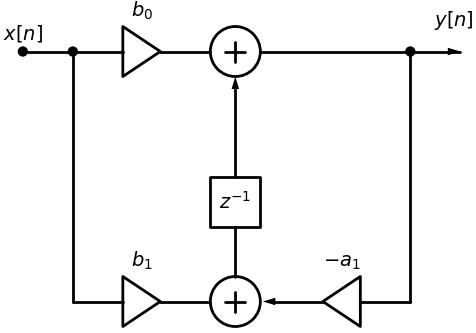

In [5]:

with schemdraw.Drawing() as d:

    d.config(unit=1, fontsize=14)
    
    e.Dot().label('$x[n]$')
    e.Line().right()
    e.Dot();
    
    d.push()
    
    e.Line().right()
    dsp.Amp().label('$b_0$')
    
    e.Line().right()

    s0 = dsp.Sum()
    
    d.pop()
    
    e.Line().down().length(5) # d='d',l=5)
    
    e.Line().right()
    dsp.Amp().label('$b_1$')
    e.Line().right()
    s1 = dsp.Sum()

    e.Line().at(s1.N).up() # d='u',xy=s1.N)

    z1 = dsp.Square().label('$z^{-1}$')    
    
    e.Arrow().up().length(2) # d='u',l=1.9)
    
    e.Line().at(s0.E).right().length(3) # d='r',xy=s0.E,l=3)
    
    d.push()
    
    e.Line().down().length(5) # , d='d',l=5)
    e.Line().left() # , d='l')
    dsp.Amp().label('$-a_1$') # ,botlabel='$-a_1$')
    e.Arrow().down().left(1.2) # , d='l',l=1.2)
    
    d.pop()
    e.Dot();
    e.Line().right() #, d='r')
    e.Arrowhead().label('$y[n]$')
    
    d.draw();

-----

----

# Frequency Distortion 

[\\]: Practical_Digital_Signal_Processing(Chap.7)

With the continuous frequency $\omega_C$ and the discrete frequency $\omega_D$,
analog and digital frequencies have the following relation:

$$
\omega_C = \frac{2}{T} \tan \left( \frac{\omega_D T}{2} \right)
$$

For small values, this can be considered linear.
The larger the values, the more distortion.

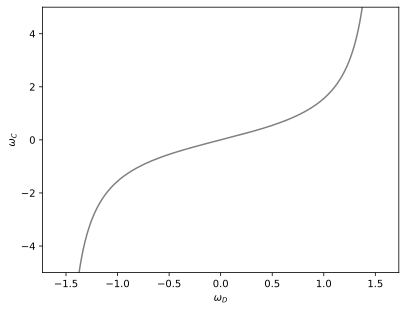

In [6]:
f = np.linspace(-np.pi/2,np.pi/2,1000)


plt.plot(f,np.tan(f),'gray')

plt.ylim([-5,5]);
plt.xlabel('$\omega_D$');
plt.ylabel('$\omega_C$');
plt.show()

## Pre-Warping

The following pre-warping is required, considering 
the cutoff frequency of the analog filter $\hat{\omega}_c$
and the cutoff frequency $\omega_0$ of the digital filter:


$$\begin{eqnarray}
jω_a &=& \frac{2}{T} \frac{1−e^{−jω_dT}}{1+e^{−jω_dT}}    \\
&=& \frac{2}{T} \frac{1−e^{−jω_dT}}{1+e^{−jω_dT}}    \\
&=& \frac{2}{T} \frac{e^{-jωd T/2}(e^{jωd T/2} − e^{−jωd T/2})}{e^{−jωd T/2}(e^{2jωd T/2} + e^{−jωd T/2})}\\
&=& \frac{2}{T} \cos\left( ω_d\frac{T}{2} \right) j \sin\left( ω_d\frac{T}{2} \right)\\
&=& j \frac{2}{T} \tan \left( ω_d\frac{T}{2} \right)
\end{eqnarray}$$



With pre-warping, any frequency - for example $\omega_c$ from the RC low-pass example -  can be corrected with the following equation:

$$
\hat{\omega}_c = \frac{2}{T} \tan \left( \frac{\omega_c T}{2} \right)
$$

The bilinear transform results in:

$$
s = \frac{\omega_c}{\tan \left( \frac{\omega_c T}{2} \right)}  \frac{1-z^{-1}}{1+z^{-1}}
$$

-----

# Exercise

By swapping R and C we can turn our first order lowpass into a highpass filter:

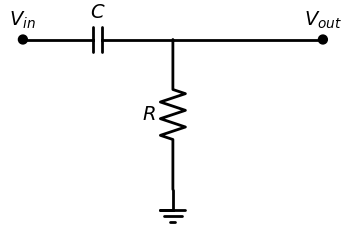

In [7]:

d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Capacitor().label('$C$'))
d.push() 

d.add(e.Resistor().down().label('$R$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()



<div class="alert alert-block alert-info"> 
<b>Apply the Bilinear Transform</b> 
    
Create an IIR filter of this circuit with the bilinear transform. 

Find expressions for $a_n$ and $b_n$.


</div>

